<a href="https://www.kaggle.com/code/manognamannala/rq3-audience-rating-prediction?scriptVersionId=316850284" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# RQ3: Audience Rating Prediction

**Research question:** How accurately can audience rating be predicted using movie-level marketing, production, genre, language, and popularity-related variables?

This Kaggle-ready notebook loads the raw CSV/Excel dataset, creates the required actual answer table(s), and saves the final figure as a PDF.

In [1]:

# =========================
# Common setup and utilities
# =========================

import os
import ast
import glob
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MultiLabelBinarizer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    r2_score, mean_absolute_error, mean_squared_error,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

RANDOM_STATE = 42

# Change this only if your Kaggle input folder has a different path.
# On Kaggle, this usually works automatically:
KAGGLE_INPUT_ROOT = "/kaggle/input"

OUTPUT_DIR = "/kaggle/working"
if not os.path.exists(OUTPUT_DIR):
    OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def find_dataset_file():
    """
    Finds the first CSV or Excel file in Kaggle input folders.
    Also works locally if the dataset is in the current folder.
    """
    search_patterns = [
        os.path.join(KAGGLE_INPUT_ROOT, "**", "*.csv"),
        os.path.join(KAGGLE_INPUT_ROOT, "**", "*.xlsx"),
        os.path.join(KAGGLE_INPUT_ROOT, "**", "*.xls"),
        "*.csv",
        "*.xlsx",
        "*.xls"
    ]
    files = []
    for pattern in search_patterns:
        files.extend(glob.glob(pattern, recursive=True))
    if not files:
        raise FileNotFoundError("No CSV or Excel dataset file found. Check Kaggle input path.")
    # Prefer files with movie-related names if multiple files exist.
    movie_like = [f for f in files if "movie" in os.path.basename(f).lower()]
    return movie_like[0] if movie_like else files[0]

def load_raw_dataset():
    file_path = find_dataset_file()
    print("Loading dataset from:", file_path)
    if file_path.lower().endswith(".csv"):
        df = pd.read_csv(file_path)
    else:
        df = pd.read_excel(file_path)
    print("Shape:", df.shape)
    return df

def safe_literal_list(x):
    """
    Converts stringified Python lists like "['Drama', 'Comedy']" into actual lists.
    Returns [] for missing or invalid values.
    """
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    if not isinstance(x, str):
        return []
    x = x.strip()
    if x == "" or x == "[]":
        return []
    try:
        val = ast.literal_eval(x)
        if isinstance(val, list):
            return [str(v).strip() for v in val if str(v).strip()]
        return []
    except Exception:
        # Fallback for comma-separated strings
        return [v.strip() for v in x.split(",") if v.strip()]

def prepare_base_dataframe(df):
    """
    Cleans and creates derived variables used across the research questions.
    """
    df = df.copy()

    # Standardize expected column names
    df.columns = [c.strip() for c in df.columns]

    # Date features
    if "release_date" in df.columns:
        df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
        df["release_year"] = df["release_date"].dt.year
        df["release_month"] = df["release_date"].dt.month
    else:
        df["release_year"] = np.nan
        df["release_month"] = np.nan

    # Ensure expected numeric columns exist
    for col in ["runtime", "popularity", "vote_average", "vote_count", "budget", "revenue"]:
        if col not in df.columns:
            df[col] = np.nan
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Parse list-like columns
    for col in ["genres", "keywords", "cast", "production_companies", "production_countries", "spoken_languages"]:
        if col not in df.columns:
            df[col] = ""
        df[col + "_list"] = df[col].apply(safe_literal_list)

    # Text variables
    for col in ["overview", "keywords", "tagline", "title", "director", "language"]:
        if col not in df.columns:
            df[col] = ""
        df[col] = df[col].fillna("").astype(str)

    # Derived variables
    df["genre_count"] = df["genres_list"].apply(len)
    df["keyword_count"] = df["keywords_list"].apply(len)
    df["cast_size"] = df["cast_list"].apply(len)
    df["production_company_count"] = df["production_companies_list"].apply(len)
    df["spoken_language_count"] = df["spoken_languages_list"].apply(len)
    df["overview_length"] = df["overview"].fillna("").astype(str).str.split().apply(len)
    df["tagline_length"] = df["tagline"].fillna("").astype(str).str.split().apply(len)
    df["has_tagline"] = (df["tagline"].str.strip() != "").astype(int)
    df["log_budget"] = np.log1p(df["budget"].fillna(0))
    df["log_revenue"] = np.log1p(df["revenue"].fillna(0))
    df["log_vote_count"] = np.log1p(df["vote_count"].fillna(0))

    # Combined text for TF-IDF
    df["combined_text"] = (
        df["overview"].fillna("") + " " +
        df["keywords"].fillna("") + " " +
        df["tagline"].fillna("")
    )

    # First genre for descriptive tables/charts
    df["primary_genre"] = df["genres_list"].apply(lambda x: x[0] if len(x) else "Unknown")

    return df

def add_top_genre_columns(df, top_n=15):
    """
    Multi-hot encodes the most frequent genres and adds them as columns.
    """
    df = df.copy()
    all_genres = pd.Series([g for sublist in df["genres_list"] for g in sublist])
    top_genres = all_genres.value_counts().head(top_n).index.tolist()
    for genre in top_genres:
        df[f"genre_{genre}"] = df["genres_list"].apply(lambda x: int(genre in x))
    return df, [f"genre_{g}" for g in top_genres]

def save_table(df, filename):
    path = os.path.join(OUTPUT_DIR, filename)
    df.to_csv(path, index=False)
    print("Saved table:", path)
    return path

def save_figure(fig, filename):
    path = os.path.join(OUTPUT_DIR, filename)
    fig.savefig(path, format="pdf", bbox_inches="tight")
    print("Saved figure:", path)
    return path

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def clean_modeling_data(df, target_col, feature_cols):
    """
    Keeps rows with non-missing target and selected features.
    """
    use_cols = list(dict.fromkeys(feature_cols + [target_col]))
    data = df[use_cols].copy()
    data = data.dropna(subset=[target_col])
    return data

def make_preprocessor(numeric_features, categorical_features):
    return ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]), numeric_features),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore", max_categories=30))
            ]), categorical_features),
            ("text", TfidfVectorizer(max_features=300, stop_words="english"), "combined_text")
        ],
        remainder="drop"
    )

def make_structured_preprocessor(numeric_features, categorical_features):
    return ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]), numeric_features),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore", max_categories=30))
            ]), categorical_features)
        ],
        remainder="drop"
    )


Loading dataset from: /kaggle/input/datasets/manognamannala/movies-analyzing-dataset/movies dataset.csv
Shape: (3053, 22)
Saved table: /kaggle/working/RQ3_rating_category_distribution.csv
Saved table: /kaggle/working/RQ3_high_rating_model_performance.csv
Saved table: /kaggle/working/RQ3_actual_answer.csv
Saved figure: /kaggle/working/RQ3_figure_rating_distribution.pdf


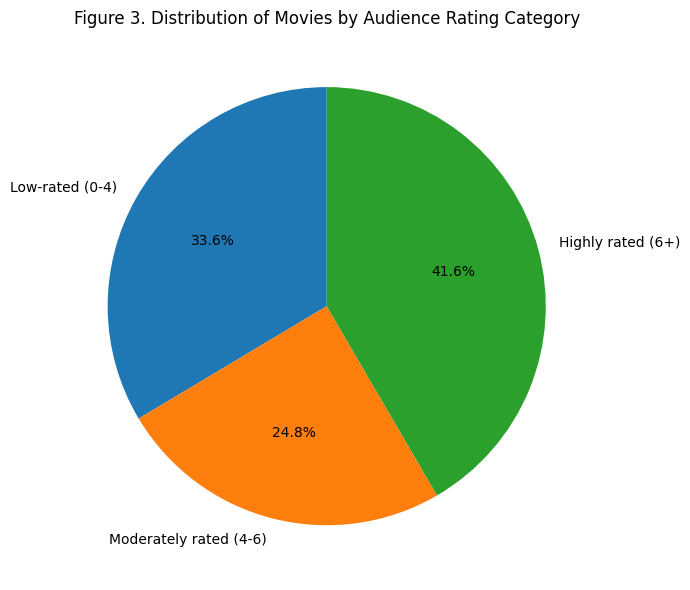

(          rating_category  number_of_movies  percentage
 1         Low-rated (0-4)              1025   33.573534
 2  Moderately rated (4-6)               758   24.828038
 0       Highly rated (6+)              1270   41.598428,
                  model target_variable  accuracy  precision    recall  \
 2    Gradient Boosting     high_rating  0.787958   0.748408  0.738994   
 1        Random Forest     high_rating  0.757853   0.728522  0.666667   
 0  Logistic Regression     high_rating  0.735602   0.695946  0.647799   
 
          f1       auc  
 2  0.743671  0.873882  
 1  0.696223  0.855480  
 0  0.671010  0.794314  )

In [2]:

df_raw = load_raw_dataset()
df = prepare_base_dataframe(df_raw)
df, genre_cols = add_top_genre_columns(df)

# Create rating categories.
def rating_category(v):
    if pd.isna(v):
        return np.nan
    if v < 4:
        return "Low-rated (0-4)"
    elif v < 6:
        return "Moderately rated (4-6)"
    else:
        return "Highly rated (6+)"

df["rating_category"] = df["vote_average"].apply(rating_category)

dist = (
    df.dropna(subset=["rating_category"])
      .groupby("rating_category")
      .size()
      .reset_index(name="number_of_movies")
)
dist["percentage"] = 100 * dist["number_of_movies"] / dist["number_of_movies"].sum()

order = ["Low-rated (0-4)", "Moderately rated (4-6)", "Highly rated (6+)"]
dist["rating_category"] = pd.Categorical(dist["rating_category"], categories=order, ordered=True)
dist = dist.sort_values("rating_category")
save_table(dist, "RQ3_rating_category_distribution.csv")

# Classification model: high rating vs. not high rating
df["high_rating"] = (df["vote_average"] >= 6).astype(int)
target = "high_rating"

numeric_features = [
    "runtime", "release_year", "release_month", "genre_count", "keyword_count",
    "cast_size", "production_company_count", "spoken_language_count",
    "overview_length", "tagline_length", "has_tagline",
    "log_budget", "log_revenue", "log_vote_count", "popularity"
] + genre_cols

categorical_features = ["language", "director", "primary_genre"]
feature_cols = numeric_features + categorical_features + ["combined_text"]
data = clean_modeling_data(df, target, feature_cols)

X = data[feature_cols]
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

preprocessor = make_preprocessor(numeric_features, categorical_features)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=250, random_state=RANDOM_STATE, n_jobs=-1, class_weight="balanced"),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE)
}

results = []
for model_name, model in models.items():
    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("model", model)
    ])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    if hasattr(pipe.named_steps["model"], "predict_proba"):
        prob = pipe.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, prob)
    else:
        auc = np.nan
    results.append({
        "model": model_name,
        "target_variable": "high_rating",
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0),
        "auc": auc
    })

model_table = pd.DataFrame(results).sort_values("f1", ascending=False)
save_table(model_table, "RQ3_high_rating_model_performance.csv")

top_cat = dist.sort_values("percentage", ascending=False).iloc[0]
best = model_table.iloc[0]
answer = pd.DataFrame([{
    "research_question": "RQ3",
    "actual_answer": f"The largest audience-rating category is {top_cat['rating_category']} ({top_cat['percentage']:.2f}%). For predicting high-rated movies, {best['model']} performed best with F1={best['f1']:.3f} and accuracy={best['accuracy']:.3f}.",
    "largest_rating_category": str(top_cat["rating_category"]),
    "largest_category_percentage": top_cat["percentage"],
    "best_model": best["model"],
    "best_f1": best["f1"],
    "best_accuracy": best["accuracy"]
}])
save_table(answer, "RQ3_actual_answer.csv")

fig, ax = plt.subplots(figsize=(7.5, 6))
ax.pie(
    dist["number_of_movies"],
    labels=dist["rating_category"].astype(str),
    autopct="%1.1f%%",
    startangle=90
)
ax.set_title("Figure 3. Distribution of Movies by Audience Rating Category")
fig.tight_layout()
save_figure(fig, "RQ3_figure_rating_distribution.pdf")
plt.show()

dist, model_table
